# import

In [1]:
import sys
sys.path.append('..')
import numpy as np
from StatTools.generators.ndfnoise_generator import ndfnoise
# from StatTools.generators.multi_scale_fractional_generator import MultiScaleFractionalGenerator
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

from collections import defaultdict
from typing import Optional, Union, Tuple

import numpy as np
from synth import gen_traj, postprocess_collisions, draw_ants_with_direction, draw_traj, build_visible_gt
from nmot import NMOT
from eval import evaluate_mot
from pathlib import Path
import pickle

In [2]:
def track(
    input_path: str,
    output_path: str = "tracked_output.mp4",
    csv_path: str = "tracks.csv",
    imshow=True,
    roi=None,
    dist2Threshold=50,
    knn_history = 100,
    pred_head = 'kalman',
    warmup_frames = 50
):
    if pred_head=='zero': pred_head=None
    
    cap = cv.VideoCapture(input_path)

    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {input_path}")

    fps = cap.get(cv.CAP_PROP_FPS)
    width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
    if output_path is not None:
        fourcc = cv.VideoWriter_fourcc(*"mp4v")
        writer = cv.VideoWriter(output_path, fourcc, fps, (width, height))

    tracker = NMOT(
        warmup_frames=warmup_frames,
        dist2Threshold=dist2Threshold,
        knn_history=knn_history,
        min_area=8,
        max_area=80,
        max_match_dist=25,
        max_missed=12,
        pred_head=pred_head,
        roi=roi,
    )

    while True:
        ok, frame = cap.read()

        if not ok:
            break

        vis, mask, active_tracks = tracker.update(frame)
        if output_path is not None: 
            writer.write(vis)

        if imshow:
            # cv2.imshow('frame', frame)
            fig, ax = plt.subplots(nrows=2)
            fig.set_size_inches((20, 10))
            
            ax[0].imshow(vis)
            ax[1].imshow(mask)
            
            plt.show()
            
            clear_output(wait=True)
            if cv.waitKey(1) & 0xFF == 27:
                cv.destroyAllWindows()
                if output_path:
                    writer.release()
                break

    cap.release()
    if output_path is not None: 
        writer.release()
    cv.destroyAllWindows()
    if csv_path:
        df = tracker.save_tracks(csv_path)

    # return df

# defs

In [3]:
def gen(config:dict, output_vid_path:str, output_csv_path:str):
    
    trajectories = gen_traj(**config)

    traj_fixed = postprocess_collisions(
        trajectories,
        radii=4.0,
        max_iter=8,
        substeps=1,
        seed=42,
    )

    draw_ants_with_direction(traj_fixed,
                             output_path=output_vid_path,
                             frame_num=config['frame_num'],
                             ants_num=config['ants_num'],
                             frame_shape=config['frame_shape'],
                             ant_length=3,
                             ant_width=1,
                             smooth_window=7,
                             imshow=False
                        )

    gt_df = build_visible_gt(
        trajectories=traj_fixed,
        frame_shape=config["frame_shape"],
        border_margin=0.0,
        min_visible_frames=1,
        first_id=1,
    )

    gt_df.to_csv(output_csv_path, index=False)
    # draw_traj(traj_fixed, config['frame_shape'], config['ants_num'], palette='bright')


def eval(gt_path, pred_path, warmup_frames:int, alpha_dist = 5.0):
    
    
    gt = pd.read_csv(gt_path)
    pred = pd.read_csv(pred_path)

    gt = gt.rename(columns={'ant_id':'track_id'})
    gt = gt[gt.frame >= warmup_frames]

    summary, accumulator = evaluate_mot(gt, pred, distance_threshold=alpha_dist)

    return summary

# solid pipe

In [4]:
for ant_num in [100, 900]:
    seeds = np.arange(1, 50, 1, dtype=int)

    config = {
        'frame_num' : 2000,
        'frame_shape' : (720, 1280),
        'margin': 100,
        'hurst_move': 1.2,
        'hurst_species': 0.5,
        'ants_num' : ant_num,
        'start_point' : None
        }

    import json
    with open(f'../data/synth_collision_gt_{ant_num}/config_{ant_num}.json', 'w') as f:
        json.dump(config, f)

    warmup_frames = 30
    metrics_dict = {}
    pred_heads = ['zero', 'kalman', 'kalman_ar1', 'lucas-kanade']
    alpha_dist = 5.0
    for seed_val in seeds:
        np.random.seed(seed_val)
        gt_vid_path = Path(f'../data/synth_collision_gt_{ant_num}/gt_{seed_val}.mp4')
        gt_csv_path = Path(f'../data/synth_collision_gt_{ant_num}/gt_{seed_val}.csv')
        
        gen(config, gt_vid_path, gt_csv_path)

        pred_head_result = []
        for pred_head in pred_heads:
            tracked_csv_path = Path(f'../data/synth_collision_tracked_{ant_num}/tracked_{pred_head}_{seed_val}.csv')
            track(input_path=gt_vid_path,
                output_path=None,
                csv_path=tracked_csv_path,
                dist2Threshold=200,
                knn_history = 200,
                imshow=False,
                pred_head=pred_head,
                warmup_frames=warmup_frames)
            
            summary = eval(gt_csv_path, tracked_csv_path, warmup_frames, alpha_dist=5.0)
            pred_head_result.append(summary.T)
        
        metrics_df = pd.concat(pred_head_result, axis=1)
        metrics_df.columns = pred_heads
        metrics_dict[seed_val] = metrics_df

    with open(f'../data/predheads_montecarlo_{ant_num}.pkl', 'wb') as f:
        pickle.dump(metrics_dict, f)

/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
/home/akhiyarov/asp/NMOT/notebooks/../synth.py:67: RuntimeWarning: Mean of empty slice.
  dx = x - trajectories[start_index:frame_idx, ant_idx, 0].mean()
/home/akhiyarov/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/akhiyarov/asp/NMOT/notebooks/../synth.py:68: RuntimeWarning: Mean of empty slice.
  dy = y - trajectories[start_index:frame_idx, ant_idx, 1].mean()
/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
/home/akhiyarov/asp/NMOT/notebooks/../synth.py:67: RuntimeWarning: Mean of empty slice.
  dx = x - 

# plot

In [103]:
metrics_dict = pd.read_pickle('../data/predheads_montecarlo.pkl')
kalman_kasdin_metrics = pd.read_pickle('../data/kalman_kasdin_metrics.pkl')
kalman_kasdin_metrics = kalman_kasdin_metrics.rename(columns={'value':'kalman-kasdin'})
metrics_df = pd.concat(metrics_dict).reset_index()
metrics_df = metrics_df.rename(columns={'level_0':'seed', 'level_1':'metric'})
metrics_df = pd.merge(metrics_df, kalman_kasdin_metrics, on=['seed', 'metric'])

In [105]:
long_metrics = pd.melt(metrics_df.drop(columns='seed'), var_name='predhead', id_vars='metric')

In [107]:
rename_metrics_dict = {
    'assa_alpha': 'AssA',
    'deta_alpha': 'DetA',
    'hota_alpha': 'HOTA',
    'idf1': 'IDF1',
    'idp': 'IDP',
    'idr': 'IDR',
    'mota': 'MOTA',
    'motp': 'MOTP',
}
rename_models_dict = {
    'zero': 'KNN', 
    'kalman': 'Kalman',
    'kalman-kasdin': 'Kalman-Kasdin AR1',
    'lucas-kanade': 'Lucas-Kanade'

}

In [108]:
long_metrics.metric = long_metrics.metric.replace(rename_metrics_dict)
long_metrics.predhead = long_metrics.predhead.replace(rename_models_dict)

In [125]:
long_metrics.to_csv('../data/mot_metrics_montecarlo_all_models.csv')

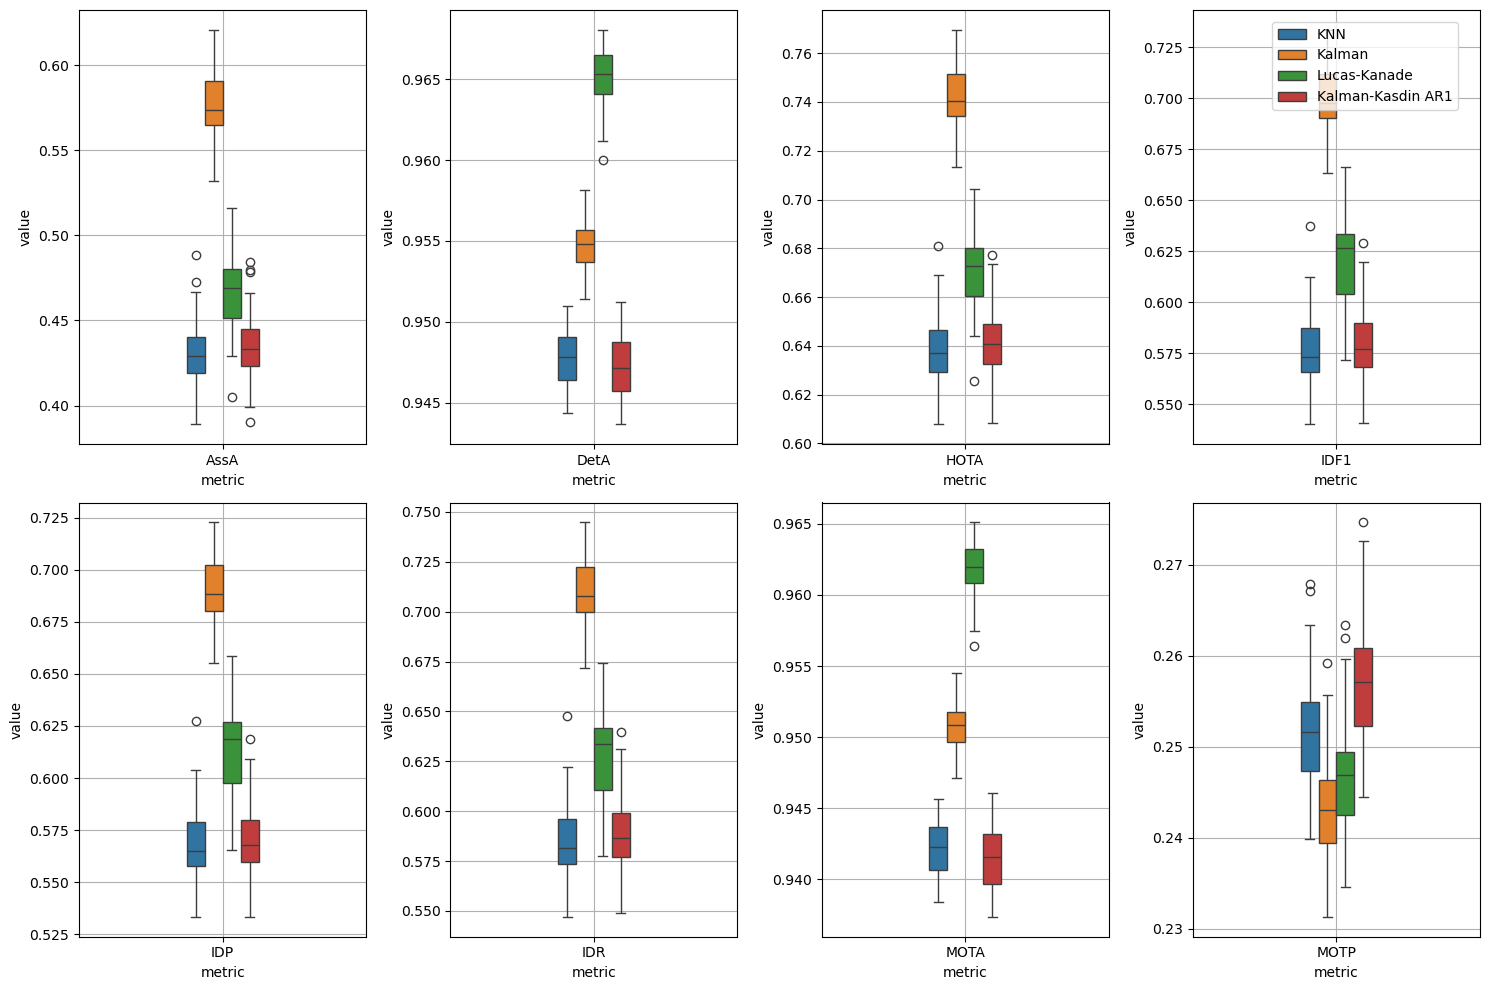

In [123]:
# id_family = ['idf1', 'idp', 'idr']
# mota_family = ['motp', 'mota']
# hota_family = ['deta_alpha', 'assa_alpha', 'hota_alpha']
target_metrics = list(rename_metrics_dict.values())
# fig, axes = plt.subplots(nrows=len(traget_metrics))
# fig.set_size_inches((10, 5*len(traget_metrics)))

# axes = axes.flatten()
ncols = 4
nrows = -(-len(target_metrics)//ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols)
axes = axes.flatten()
fig.set_size_inches((15, 10))
for idx, ax in enumerate(axes):
    sns.boxplot(long_metrics.loc[long_metrics.metric==target_metrics[idx]], y='value', x='metric', hue='predhead', orient='v', ax=ax, width=0.25)
    ax.grid()
    ax.legend().set_visible(False)
# plt.legend(False)
handles, labels = axes[-1].get_legend_handles_labels()
# fig.legend().set_visible(False)  # удаляем оригинальную легенду
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=10)
plt.tight_layout()
plt.show()

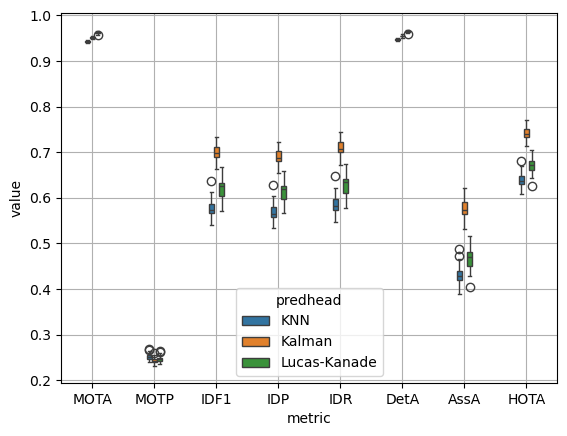

In [89]:
sns.boxplot(long_metrics.loc[long_metrics.metric.isin(target_metrics)], y='value', x='metric', hue='predhead', orient='v', width=0.25)
plt.grid()